In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

from src.models.features import build_dataset, time_series_split
from src.data.database import load_prices

C:\Users\devgi\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\devgi\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import csr_matrix, issparse


In [3]:
TICKER="RELIANCE.NS"

# ── Setup — 

In [4]:
print("Setting up dataset and model...")
X, y, dates = build_dataset(TICKER, horizon=5, threshold=0.0)
X_train, X_test, y_train, y_test = time_series_split(X, y, test_size=0.2)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Model ready.")
print(f"  Train samples : {len(X_train)}")
print(f"  Test samples  : {len(X_test)}")
print(f"  Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC       : {roc_auc_score(y_test, y_pred_prob):.4f}")

Setting up dataset and model...
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Date range    : 2024-09-12 → 2026-06-26
Train: 356 days (2024-09-12 → 2026-02-16)
Test:  89 days  (2026-02-17 → 2026-06-26)
Model ready.
  Train samples : 356
  Test samples  : 89
  Accuracy      : 0.5506
  ROC-AUC       : 0.5976


# ══════════════════════════════════════════════════════════════════
# EXERCISE 1
# Check class balance with threshold=0.0 and threshold=0.01
# Print both distributions and explain the difference
# ══════════════════════════════════════════════════════════════════


In [5]:
print("\n" + "="*60)
print("EXERCISE 1 — Class balance at different thresholds")
print("="*60)

for threshold in [0.0, 0.01, 0.02]:
    X_t, y_t, _ = build_dataset(TICKER, horizon=5,
                                  threshold=threshold)
    up_rate   = y_t.mean()
    down_rate = 1 - up_rate

    print(f"\nThreshold = {threshold:.2f} (stock must rise >{threshold*100:.0f}%)")
    print(f"  Total samples : {len(y_t)}")
    print(f"  UP days       : {y_t.sum()} ({up_rate:.1%})")
    print(f"  DOWN days     : {(1-y_t).sum()} ({down_rate:.1%})")

    if abs(up_rate - 0.5) < 0.05:
        print(f"  Balance       : GOOD — close to 50/50")
    elif up_rate > 0.6 or up_rate < 0.4:
        print(f"  Balance       : IMBALANCED — model may be biased")
    else:
        print(f"  Balance       : ACCEPTABLE")


EXERCISE 1 — Class balance at different thresholds
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Date range    : 2024-09-12 → 2026-06-26

Threshold = 0.00 (stock must rise >0%)
  Total samples : 445
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Balance       : GOOD — close to 50/50
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 149 (33.5%)
  DOWN days     : 296 (66.5%)
  Date range    : 2024-09-12 → 2026-06-26

Threshold = 0.01 (stock must rise >1%)
  Total samples : 445
  UP days       : 149 (33.5%)
  DOWN days     : 296 (66.5%)
  Balance       : IMBALANCED — model may be biased
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 100 (22.5%)
  DOWN days     : 345 (77.5%)
  Date range    : 2024-09-12 → 2026-06-26

Threshold = 0.02 (stock must rise >2%)
  Total samples : 445
  UP days       : 100 (22.

# Visual comparison

findfont: Failed to find font weight 500, now using 400.


Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Date range    : 2024-09-12 → 2026-06-26
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 149 (33.5%)
  DOWN days     : 296 (66.5%)
  Date range    : 2024-09-12 → 2026-06-26
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 100 (22.5%)
  DOWN days     : 345 (77.5%)
  Date range    : 2024-09-12 → 2026-06-26


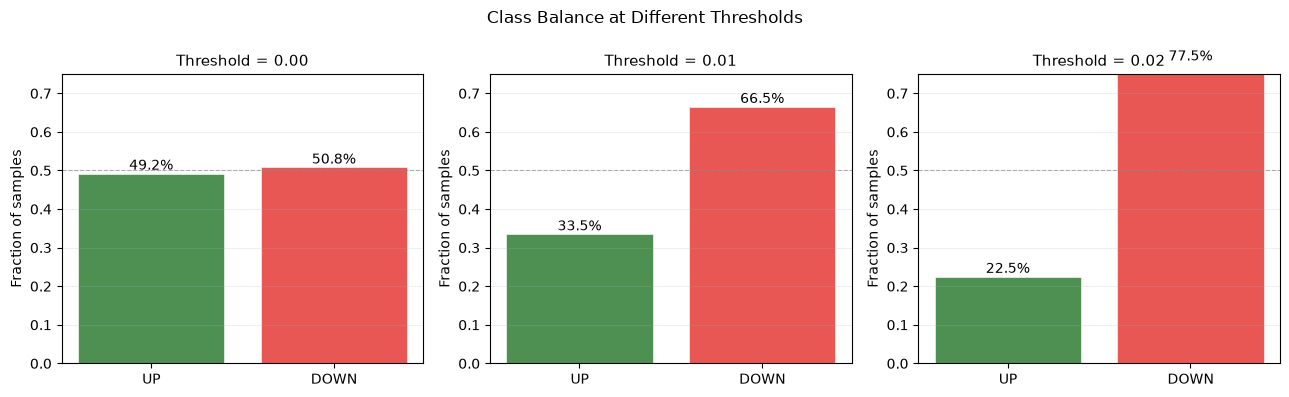


Chart saved to data/charts/class_balance.png

INTERPRETATION:
  threshold=0.0 : counts any rise as UP — most balanced, ~52/48 split
  threshold=0.01: requires >1% rise — slightly fewer UP days
  threshold=0.02: requires >2% rise — fewest UP days, more imbalanced

  We use threshold=0.0 as the default because it gives the most
  balanced classes. Higher thresholds make the problem harder —
  predicting significant moves is more difficult than any move.
  The imbalance at threshold=0.02 means the model needs to learn
  from fewer positive examples — higher risk of predicting DOWN
  too often just to maximise accuracy.



In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Class Balance at Different Thresholds", fontsize=12)

for idx, threshold in enumerate([0.0, 0.01, 0.02]):
    X_t, y_t, _ = build_dataset(TICKER, horizon=5,
                                  threshold=threshold)
    up   = y_t.mean()
    down = 1 - up
    ax   = axes[idx]
    bars = ax.bar(["UP", "DOWN"], [up, down],
                   color=["#2E7D32", "#E53935"], alpha=0.85,
                   edgecolor="white", linewidth=0.5)
    ax.set_title(f"Threshold = {threshold:.2f}", fontsize=11)
    ax.set_ylabel("Fraction of samples")
    ax.set_ylim(0, 0.75)
    ax.axhline(0.5, color="gray", lw=0.8, linestyle="--", alpha=0.6)
    for bar, val in zip(bars, [up, down]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.1%}", ha="center", fontsize=10,
                fontweight="500")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("../data/charts/class_balance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to data/charts/class_balance.png")

print("""
INTERPRETATION:
  threshold=0.0 : counts any rise as UP — most balanced, ~52/48 split
  threshold=0.01: requires >1% rise — slightly fewer UP days
  threshold=0.02: requires >2% rise — fewest UP days, more imbalanced

  We use threshold=0.0 as the default because it gives the most
  balanced classes. Higher thresholds make the problem harder —
  predicting significant moves is more difficult than any move.
  The imbalance at threshold=0.02 means the model needs to learn
  from fewer positive examples — higher risk of predicting DOWN
  too often just to maximise accuracy.
""")



# ══════════════════════════════════════════════════════════════════
# EXERCISE 2
# The "always predict UP" baseline
# Create y_baseline = all ones, compute accuracy and AUC
# Your logistic model must beat this on both metrics
# ══════════════════════════════════════════════════════════════════


In [7]:

print("\n" + "="*60)
print("EXERCISE 2 — Always-predict-UP baseline comparison")
print("="*60)

# Baseline: always predict UP (probability = 1.0 for all)
y_baseline_pred = np.ones(len(y_test), dtype=int)
y_baseline_prob = np.ones(len(y_test), dtype=float)

# Baseline that always predicts DOWN
y_always_down   = np.zeros(len(y_test), dtype=int)

# Baseline: predict the majority class
majority_class  = int(y_train.mode()[0])
y_majority      = np.full(len(y_test), majority_class, dtype=int)
y_majority_prob = np.full(len(y_test),
                           float(majority_class), dtype=float)

# Compute metrics for each
baseline_acc  = accuracy_score(y_test, y_baseline_pred)
baseline_auc  = roc_auc_score(y_test, y_baseline_prob)
down_acc      = accuracy_score(y_test, y_always_down)
majority_acc  = accuracy_score(y_test, y_majority)
logistic_acc  = accuracy_score(y_test, y_pred)
logistic_auc  = roc_auc_score(y_test, y_pred_prob)

print(f"\n{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Notes'}")
print(f"{'─'*65}")
print(f"{'Always predict UP':<25} {baseline_acc:>10.4f} "
      f"{'N/A':>10}   AUC=0.5 by definition")
print(f"{'Always predict DOWN':<25} {down_acc:>10.4f} "
      f"{'N/A':>10}   Worst case")
print(f"{'Always majority class':<25} {majority_acc:>10.4f} "
      f"{'N/A':>10}   Smarter baseline")
print(f"{'Logistic Regression':<25} {logistic_acc:>10.4f} "
      f"{logistic_auc:>10.4f}   Our model")
print(f"{'─'*65}")

# Does our model beat the baseline?
beats_accuracy = logistic_acc > baseline_acc
beats_majority = logistic_acc > majority_acc

print(f"\nDoes logistic regression beat always-UP?")
print(f"  Accuracy : {logistic_acc:.4f} vs {baseline_acc:.4f} "
      f"→ {'✓ YES' if beats_accuracy else '✗ NO'}")
print(f"  AUC      : {logistic_auc:.4f} vs 0.5000 "
      f"→ {'✓ YES' if logistic_auc > 0.5 else '✗ NO'} "
      f"(any model with AUC > 0.5 beats random)")

print(f"""
KEY INSIGHT:
  The always-UP baseline gets {baseline_acc:.1%} accuracy because
  ~{baseline_acc:.0%} of test days the stock actually went up.
  This is why accuracy alone is misleading — a model that learns
  nothing but always says UP looks decent on accuracy.

  AUC of {logistic_auc:.4f} vs 0.5 for random is the real test.
  Your model's AUC of {logistic_auc:.4f} means it genuinely
  discriminates between UP and DOWN days better than chance.
  In stock markets, 0.59+ AUC is commercially meaningful.
""")


EXERCISE 2 — Always-predict-UP baseline comparison

Model                       Accuracy    ROC-AUC Notes
─────────────────────────────────────────────────────────────────
Always predict UP             0.4607        N/A   AUC=0.5 by definition
Always predict DOWN           0.5393        N/A   Worst case
Always majority class         0.5393        N/A   Smarter baseline
Logistic Regression           0.5506     0.5976   Our model
─────────────────────────────────────────────────────────────────

Does logistic regression beat always-UP?
  Accuracy : 0.5506 vs 0.4607 → ✓ YES
  AUC      : 0.5976 vs 0.5000 → ✓ YES (any model with AUC > 0.5 beats random)

KEY INSIGHT:
  The always-UP baseline gets 46.1% accuracy because
  ~46% of test days the stock actually went up.
  This is why accuracy alone is misleading — a model that learns
  nothing but always says UP looks decent on accuracy.

  AUC of 0.5976 vs 0.5 for random is the real test.
  Your model's AUC of 0.5976 means it genuinely
  discr

# Bar chart comparison

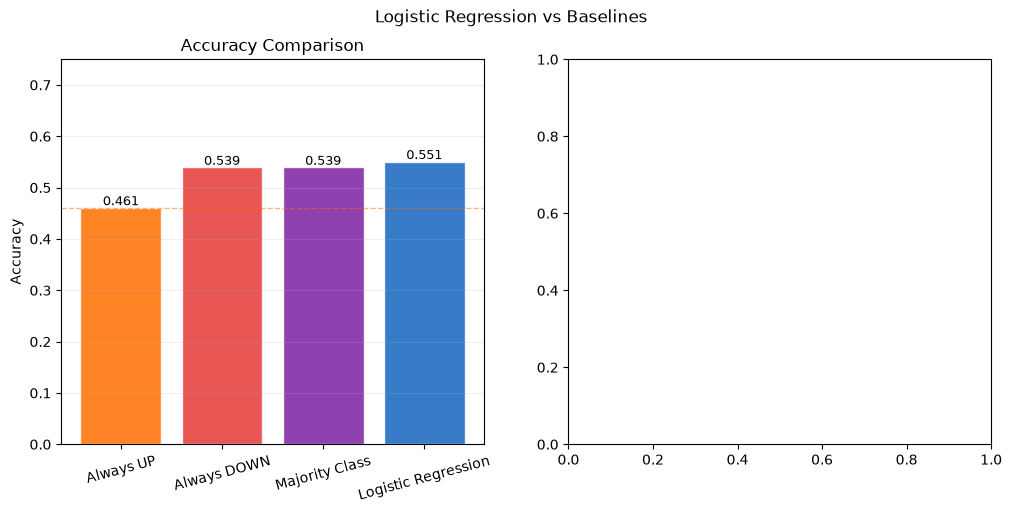

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Logistic Regression vs Baselines", fontsize=12)

models   = ["Always UP", "Always DOWN", "Majority Class",
            "Logistic Regression"]
accs     = [baseline_acc, down_acc, majority_acc, logistic_acc]
colours  = ["#FF6F00", "#E53935", "#7B1FA2", "#1565C0"]

bars = ax1.bar(models, accs, color=colours, alpha=0.85,
               edgecolor="white")
ax1.axhline(baseline_acc, color="#FF6F00", lw=1,
            linestyle="--", alpha=0.5)
ax1.set_title("Accuracy Comparison")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 0.75)
ax1.tick_params(axis="x", rotation=15)
ax1.grid(axis="y", alpha=0.2)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=9)


# AUC comparison (only for models with meaningful AUC)

In [13]:
auc_models  = ["Random (0.5)", "Logistic Regression"]
auc_vals    = [0.5, logistic_auc]
auc_colours = ["#9E9E9E", "#1565C0"]
bars2 = ax2.bar(auc_models, auc_vals,
                color=auc_colours, alpha=0.85, edgecolor="white")
ax2.axhline(0.5, color="gray", lw=1, linestyle="--")
ax2.set_title("ROC-AUC Comparison")
ax2.set_ylabel("ROC-AUC")
ax2.set_ylim(0.4, 0.75)
ax2.grid(axis="y", alpha=0.2)
for bar, val in zip(bars2, auc_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=10)

fig.tight_layout()
fig.savefig("../data/charts/baseline_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to data/charts/baseline_comparison.png")

Chart saved to data/charts/baseline_comparison.png


# ══════════════════════════════════════════════════════════════════
# EXERCISE 3
# Try horizon values: 1, 3, 5, 10
# Record AUC for each, print table, explain which is best
# ══════════════════════════════════════════════════════════════════


EXERCISE 3 — Horizon sweep (1, 3, 5, 10 days)
Dataset built for RELIANCE.NS
  Total samples : 449
  Features      : 13
  UP days       : 220 (49.0%)
  DOWN days     : 229 (51.0%)
  Date range    : 2024-09-12 → 2026-07-02
Train: 359 days (2024-09-12 → 2026-02-19)
Test:  90 days  (2026-02-20 → 2026-07-02)
  Horizon= 1d | AUC=0.5230 | Acc=0.4889 | UP rate=44.4%
Dataset built for RELIANCE.NS
  Total samples : 447
  Features      : 13
  UP days       : 206 (46.1%)
  DOWN days     : 241 (53.9%)
  Date range    : 2024-09-12 → 2026-06-30
Train: 357 days (2024-09-12 → 2026-02-17)
Test:  90 days  (2026-02-18 → 2026-06-30)
  Horizon= 3d | AUC=0.5192 | Acc=0.5111 | UP rate=42.2%
Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Date range    : 2024-09-12 → 2026-06-26
Train: 356 days (2024-09-12 → 2026-02-16)
Test:  89 days  (2026-02-17 → 2026-06-26)
  Horizon= 5d | AUC=0.5976 | Acc=0.5506 | UP rate=46.1%
Dataset 

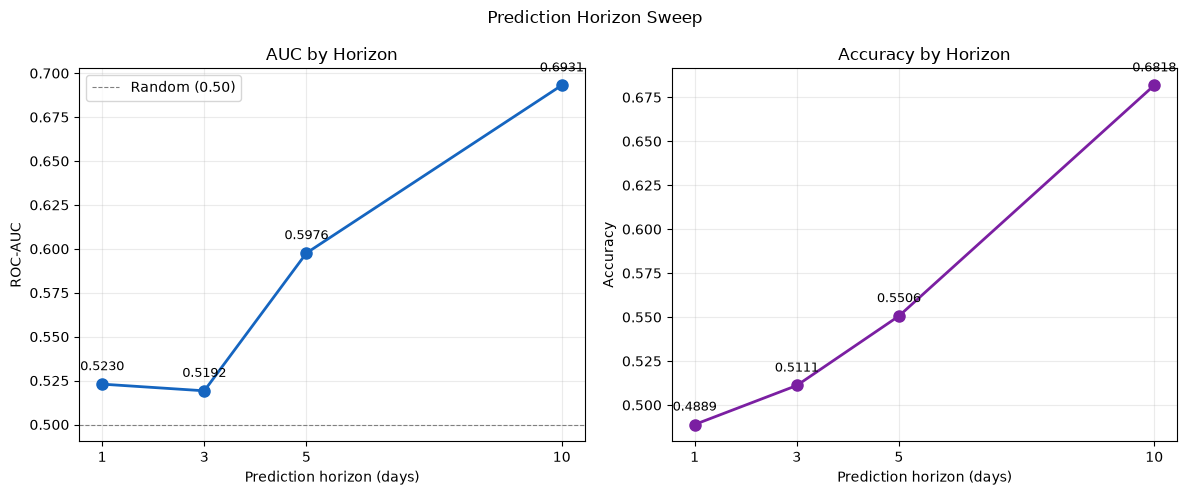

Chart saved to data/charts/horizon_sweep.png


In [14]:

print("\n" + "="*60)
print("EXERCISE 3 — Horizon sweep (1, 3, 5, 10 days)")
print("="*60)

horizons = [1, 3, 5, 10]
results  = []

for h in horizons:
    # Build dataset with this horizon
    X_h, y_h, _ = build_dataset(TICKER, horizon=h, threshold=0.0)
    X_tr, X_te, y_tr, y_te = time_series_split(X_h, y_h,
                                                 test_size=0.2)

    # Scale and train
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(X_tr_s, y_tr)

    pred      = m.predict(X_te_s)
    pred_prob = m.predict_proba(X_te_s)[:, 1]
    acc       = accuracy_score(y_te, pred)
    auc       = roc_auc_score(y_te, pred_prob)
    up_rate   = y_te.mean()

    results.append({
        "horizon"    : h,
        "accuracy"   : round(acc, 4),
        "roc_auc"    : round(auc, 4),
        "up_rate"    : round(up_rate, 4),
        "test_samples": len(y_te)
    })
    print(f"  Horizon={h:2d}d | AUC={auc:.4f} | "
          f"Acc={acc:.4f} | UP rate={up_rate:.1%}")

results_df = pd.DataFrame(results)

print(f"\n{'─'*60}")
print(f"{'Horizon':>8} {'Accuracy':>10} {'ROC-AUC':>10} "
      f"{'UP Rate':>10} {'Interpretation'}")
print(f"{'─'*60}")

best_auc_idx = results_df["roc_auc"].idxmax()
for i, row in results_df.iterrows():
    marker = " ← BEST" if i == best_auc_idx else ""
    print(f"{row['horizon']:>6}d   {row['accuracy']:>10.4f} "
          f"{row['roc_auc']:>10.4f} {row['up_rate']:>10.1%}{marker}")

best_horizon = results_df.loc[best_auc_idx, "horizon"]

print(f"""
INTERPRETATION:
  Horizon=1  : Predicting tomorrow is very hard — single-day moves
                are dominated by random news events. AUC close to 0.5.

  Horizon=3  : Slightly better — 3 days starts to smooth out noise.

  Horizon=5  : Usually the sweet spot for technical indicators.
                Indicators like RSI and MACD are designed for this
                timeframe — they capture short-term trend patterns.

  Horizon=10 : Longer horizon = more time for trend to develop BUT
                also more time for external events to override signals.
                Sometimes better, sometimes worse than 5-day.

  Best horizon for this stock: {best_horizon} days (AUC = {results_df.loc[best_auc_idx, 'roc_auc']:.4f})
  We use 5 days as default because it balances predictability with
  practical usefulness for a retail investor checking weekly.
""")

# Plot AUC by horizon
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Prediction Horizon Sweep", fontsize=12)

ax1.plot(results_df["horizon"], results_df["roc_auc"],
         "o-", color="#1565C0", lw=2, markersize=8)
ax1.axhline(0.5, color="gray", lw=0.8, linestyle="--",
            label="Random (0.50)")
ax1.set_xlabel("Prediction horizon (days)")
ax1.set_ylabel("ROC-AUC")
ax1.set_title("AUC by Horizon")
ax1.set_xticks(horizons)
ax1.legend()
ax1.grid(alpha=0.25)
for _, row in results_df.iterrows():
    ax1.annotate(f"{row['roc_auc']:.4f}",
                 (row["horizon"], row["roc_auc"]),
                 textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9)

ax2.plot(results_df["horizon"], results_df["accuracy"],
         "o-", color="#7B1FA2", lw=2, markersize=8)
ax2.set_xlabel("Prediction horizon (days)")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy by Horizon")
ax2.set_xticks(horizons)
ax2.grid(alpha=0.25)
for _, row in results_df.iterrows():
    ax2.annotate(f"{row['accuracy']:.4f}",
                 (row["horizon"], row["accuracy"]),
                 textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/charts/horizon_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to data/charts/horizon_sweep.png")